In [132]:
from langchain_ollama import ChatOllama
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages 
from typing import TypedDict, Annotated, List
from pydantic import BaseModel, Field
from langchain_core.messages import BaseMessage, HumanMessage, SystemMessage, AIMessage
from langchain_huggingface import HuggingFaceEmbeddings
import faiss
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_core.tools import tool
from langgraph.types import interrupt, Command
from langgraph.checkpoint.memory import InMemorySaver
import operator
import random
import os
import numpy as np
import getpass
from dotenv import load_dotenv

In [133]:
class State(TypedDict):
    alert: str
    messages: Annotated[List[BaseMessage], add_messages]
    active_hypothesis: str
    telemetry_data: Annotated[List[dict], operator.add] 
    proposed_patch: str 
    human_feedback: str 
    human_message: str | None 

class AlertRouter(BaseModel):
    status_code: str = Field(..., description="The error code extracted from the alert")
    description: str = Field(..., description="A detailed description of the error based on the alert")


In [134]:
print("Loading vector model...")
embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")

Loading vector model...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2026.54it/s]


In [135]:
PATH = "rag_swarm"
VECTOR_STORE_DIR = "vector_store"
INDEX_FILE = os.path.join(VECTOR_STORE_DIR, "vector.index")

GLOBAL_FAISS_INDEX = None
GLOBAL_DOCS = []

In [136]:
def load_vector_store():
    global GLOBAL_FAISS_INDEX, GLOBAL_DOCS

    # Always loading the documents so that we can map the indices back to text
    for file in os.listdir(PATH):
        with open(os.path.join(PATH, file), 'r', encoding='utf-8') as f:
            GLOBAL_DOCS.append(f.read())
    
    if not GLOBAL_DOCS:
        raise ValueError("No documents found in the specified path.")
    
    if os.path.exists(INDEX_FILE):
        print("Loading FAISS index from disk...")
        GLOBAL_FAISS_INDEX = faiss.read_index(INDEX_FILE)
        return
    
    print("Building new FAISS index...")
    if not os.path.exists(VECTOR_STORE_DIR):
        os.makedirs(VECTOR_STORE_DIR)
    
    vectors = embeddings.embed_documents(GLOBAL_DOCS)
    vectors = np.array(vectors, dtype=np.float32)

    dimensions = vectors.shape[1]
    GLOBAL_FAISS_INDEX = faiss.IndexFlatL2(dimensions)
    GLOBAL_FAISS_INDEX.add(vectors)

    faiss.write_index(GLOBAL_FAISS_INDEX, INDEX_FILE)


load_vector_store() #firing the vector store so that we can get the store ready with documents


Loading FAISS index from disk...


In [137]:
@tool 
def query_datadog():
    """Queries Datadog for logs from the Ashford Tourney Cluster."""
    if random.random() < 0.30:
        raise Exception("Datadog API Timeout: Connection severed by Aerion Brightflame's firewall rules!")
    return [
        "Error: 'Tanselle' Database connection failed. Shield wall compromised.",
        "Warning: High memory usage detected in 'Hedge_Knight' service.",
    ]

@tool
def query_prometheus():
    """Queries Prometheus for metrics from the Ashford Tourney Cluster."""
    return ["CPU usage: 85% in 'Baelor_Breakspear' node (Threshold: 80%)"]

@tool
def search_internal_docs(query: str):
    """Searches the internal documentation and returns relevant runbooks."""
    vector_query = embeddings.embed_query(query)
    vector_query = np.array([vector_query], dtype=np.float32)
    k = min(2, len(GLOBAL_DOCS))
    _, indices = GLOBAL_FAISS_INDEX.search(vector_query, k)
    response = [GLOBAL_DOCS[i] for i in indices[0] if i != -1]
    return response


In [138]:
# load_dotenv() # Load environment variables from .env file if it exists
# if 'GROQ_API_KEY' not in os.environ:
#     os.environ['GROQ_API_KEY'] = getpass.getpass("Enter your GROQ API key: ")

# llm = ChatGroq(
#     model="llama-3.3-70b-versatile",
#     temperature=0, # Keep it at 0 for deterministic, analytical SRE tasks
#     max_retries=2, # Built-in retry logic in case of network blips
# )
llm = ChatOllama(model="llama3.1")
print("Chat Model loaded successfully.")

Chat Model loaded successfully.


In [139]:
def create_subgraphs(tools_list, master_prompt):
    """Creates an isolated agent with it's tool node."""
    class SubState(TypedDict):
        messages: Annotated[List[BaseMessage], add_messages]
        active_hypothesis: str

    llm_with_tools = llm.bind_tools(tools_list)

    def agent_node(state: SubState):
        sys_msg = [SystemMessage(content=f"""
        {master_prompt}
        Current active hypothesis: {state['active_hypothesis']}
    """)]
        messages = sys_msg + state['messages']
        return {"messages": [llm_with_tools.invoke(messages)]}

    tool_node = ToolNode(tools_list, handle_tool_errors=True)
    builder = StateGraph(SubState)
    builder.add_node("agent", agent_node)
    builder.add_node("tools", tool_node)
    builder.add_edge(START, "agent")
    builder.add_conditional_edges("agent", tools_condition)
    builder.add_edge("tools", "agent")
    return builder.compile()

In [140]:
log_subgraph = create_subgraphs([query_datadog], "You are a log analyzer. You receive the active hypothesis and you need to analyze the logs from datadog.")
metric_subgraph = create_subgraphs([query_prometheus], "You are a metric fetcher. You receive the active hypothesis and you need to analyze the metrics from prometheus.")
rag_subgraph = create_subgraphs([search_internal_docs], "You are a runbook researcher. You receive the active hypothesis and you need to search the internal documentation for relevant information.")

def alert_router(state: State):
    prompt = [SystemMessage(content=f"Analyze the alert and provide a description with the error code. Alert: {state['alert']}")]
    response = llm.with_structured_output(AlertRouter).invoke(prompt)
    return {'messages': [AIMessage(content=f"Error Code: {response.status_code}\nDescription: {response.description}")]}


def sre_supervisor(state: State):
    prompt = [SystemMessage(content=f"Formulate a concise active hypothesis based on this analysis: {state['messages'][-1].content}")]
    response = llm.invoke(prompt)
    return {'messages' : [AIMessage(content=response.content)], 'active_hypothesis' : response.content}



def log_analyzer(state: State):
    result = log_subgraph.invoke({'messages' : [], 'active_hypothesis' : state['active_hypothesis']})
    return {'telemetry_data' : [{'source' : 'datadog', 'summary' : result['messages'][-1].content}]}

def metric_fetcher(state: State):
    result = metric_subgraph.invoke({'messages' : [], 'active_hypothesis' : state['active_hypothesis']})
    return {'telemetry_data' : [{'source' : 'prometheus', 'summary' : result['messages'][-1].content}]}

def runbook_researcher(state: State):
    result = rag_subgraph.invoke({'messages' : [], 'active_hypothesis' : state['active_hypothesis']})
    return {'telemetry_data' : [{'source' : 'internal_docs', 'summary' : result['messages'][-1].content}]}

def remediator(state: State):
    # FIX: Use .get() to safely check for keys that might not exist in the first pass
    if not state.get('human_feedback'):
        prompt = [SystemMessage(content=f"""You are a remediator. You receive the active hypothesis, telemetry data and the relevant information from the internal documentation and you need to provide a proposed patch for the given alert.
                           RULE:The proposed patch should be based on the active hypothesis, telemetry data and the relevant information from the internal documentation. It should be concise and should not contain any irrelevant information.
                           Active Hypothesis: {state.get('active_hypothesis', 'None')}
                           Telemetry Data: {state.get('telemetry_data', [])}
                           Relevant Information: {state.get('rag_response', 'None')}
                           """)]
    else:
        prompt = [SystemMessage(content=f"""You are a remediator. You receive the active hypothesis, telemetry data, relevant information from the internal documentation and the human feedback and you need to provide a proposed patch for the given alert.
                           RULE:The proposed patch should be based on the active hypothesis, telemetry data, relevant information from the internal documentation and the human feedback. It should be concise and should not contain any irrelevant information.
                           Active Hypothesis: {state.get('active_hypothesis', 'None')}
                           Telemetry Data: {state.get('telemetry_data', [])}
                           Relevant Information: {state.get('rag_response', 'None')}
                           Human Feedback: {state.get('human_feedback')}
                           Human Message: {state.get('human_message')}
                           """)]
                           
    response = llm.invoke(prompt)
    return {'proposed_patch' : response.content}
    response = llm.invoke(prompt)
    return {'proposed_patch' : response.content}

def human_feedback(state: State) -> State:
    decision = interrupt({
        "type" : "human_feedback",
        "message": "Please provide your feedback on the proposed patch. Do you approve or disapprove of the proposed patch? If you disapprove, please provide your reasoning.",
        "instructions" : "Please provide your feedback in the following format: \n\n '{'decision' : 'approve' or 'disapprove', 'reasoning' : 'your reasoning for disapproving the proposed patch if you disapprove'}'" 
    })
    return {'human_feedback' : decision['decision'], 'human_message' : decision['reasoning']}

def human_router(state: State):
    if state['human_feedback'] == 'approve':
        return "END"
    else:
        return "REMEDIATOR"

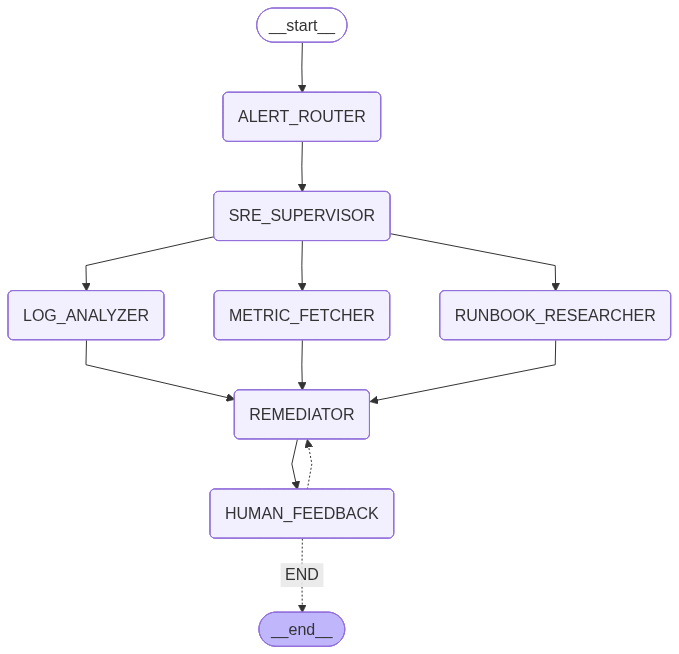

In [141]:
checkpointer = InMemorySaver()
graph = StateGraph(State)

graph.add_node("ALERT_ROUTER", alert_router)
graph.add_node("SRE_SUPERVISOR", sre_supervisor)
graph.add_node("LOG_ANALYZER", log_analyzer)
graph.add_node("METRIC_FETCHER", metric_fetcher)
graph.add_node("RUNBOOK_RESEARCHER", runbook_researcher)
graph.add_node("REMEDIATOR", remediator)
graph.add_node("HUMAN_FEEDBACK", human_feedback)

graph.add_edge(START, "ALERT_ROUTER")
graph.add_edge("ALERT_ROUTER", "SRE_SUPERVISOR")
graph.add_edge("SRE_SUPERVISOR", "LOG_ANALYZER")
graph.add_edge("SRE_SUPERVISOR", "METRIC_FETCHER")
graph.add_edge("SRE_SUPERVISOR", "RUNBOOK_RESEARCHER")
graph.add_edge("LOG_ANALYZER", "REMEDIATOR")
graph.add_edge("METRIC_FETCHER", "REMEDIATOR")
graph.add_edge("RUNBOOK_RESEARCHER", "REMEDIATOR")
graph.add_edge("REMEDIATOR", "HUMAN_FEEDBACK")
graph.add_conditional_edges("HUMAN_FEEDBACK", human_router, {
    "END" : END,
    "REMEDIATOR" : "REMEDIATOR"
})

model = graph.compile(checkpointer=checkpointer)
model

In [142]:
import uuid
config = {'configurable': {'thread_id': str(uuid.uuid4())}}
initial_state = {
    "alert": "CRITICAL 500: The 'Tanselle' Database in the Ashford cluster is rejecting connections. Shield wall is down.",
    "telemetry_data": []
}

print("🛡️ --- PHASE 1: AUTONOMOUS SWARM INVESTIGATION --- 🛡️")
for event in model.stream(initial_state, config=config, stream_mode='updates'):
    for node_name, state_update in event.items():
        print(f"\n[NODE EXECUTED: {node_name}]")

        if 'active_hypothesis' in state_update:
            print(f"-> Hypothesis Formulated: {state_update['active_hypothesis']}")
        if 'telemetry_data' in state_update:
            print(f"-> Data Gathered: {state_update['telemetry_data']}")
        if 'proposed_patch' in state_update:
            print(f"-> Drafted Patch:\n{state_update['proposed_patch']}")

print("\n🛡️ --- PHASE 2: HUMAN FEEDBACK & ITERATION --- 🛡️")
current_state = model.get_state(config)
pending_patch = current_state.values.get('proposed_patch', 'No patch proposed.')
print(f"\nProposed Patch for Review:\n{pending_patch}")

human_response = {
    "decision": "disapprove",
    "reasoning": "The proposed patch does not address the root cause of the database connection issue. It only attempts to mitigate the symptoms without fixing the underlying problem."
}

print(f"Human decision: {human_response['decision'].upper()}")
print(f"Human reasoning: {human_response['reasoning']}")

print("🔄 --- RESUMING GRAPH --- 🔄")
for event in model.stream(Command(resume=human_response), config=config, stream_mode='updates'):
    for node_name, state_update in event.items():
        print(f"\n[NODE EXECUTED: {node_name}]")
        
        if 'proposed_patch' in state_update:
            print(f"-> REVISED PATCH:\n{state_update['proposed_patch']}")
            
print("\n✅ --- INCIDENT RESOLVED --- ✅")

🛡️ --- PHASE 1: AUTONOMOUS SWARM INVESTIGATION --- 🛡️

[NODE EXECUTED: ALERT_ROUTER]

[NODE EXECUTED: SRE_SUPERVISOR]
-> Hypothesis Formulated: assistant

Here is a concise and active hypothesis:

"I hypothesize that the error 'Connection was refused' is caused by an incorrect configuration of our data source settings, which are preventing the system from establishing a successful connection."

[NODE EXECUTED: RUNBOOK_RESEARCHER]
-> Data Gathered: [{'source': 'internal_docs', 'summary': 'assistant\n\nI\'ve searched our internal documentation for relevant information regarding the active hypothesis "assistant".\n\nHere\'s what I found:\n\n**Connection was refused error**\n\nThe "Connection was refused" error typically indicates that the system is unable to establish a connection with the data source due to incorrect configuration or network issues.\n\n**Data Source Settings Configuration**\n\nOur documentation recommends verifying the following settings in the data source configuration: